# Entrenamiento del modelo de regresión logística para predecir púlsars sobre HTRU2

## Preparación de los datos

### Carga del dataset 

Importo los datos. X son las features (características) e y son los targets (0 o 1 según sean o no púlsar).

In [3]:
from ucimlrepo import fetch_ucirepo

htru2 = fetch_ucirepo(id=372)
X = htru2.data.features
y = htru2.data.targets

## Train/test split 

Voy a separar los datos en dos grupos. 

El primer grupo para entrenar el modelo. (train)
El segundo grupo para probar el modelo. (test)

Esto se podría hacer con sklearn, como más adelante pero para entenderlo prefiero hacerlo manualmente:

Reservamos el 20% de los datos para testear el modelo.

In [4]:
import numpy as np

indices_mezclados = np.random.permutation(17897)
X_mezclado = X.iloc[indices_mezclados]
y_mezclado = y.iloc[indices_mezclados]

X_train = X_mezclado.iloc[:14318]
X_test = X_mezclado.iloc[14318:]
y_train = y_mezclado.iloc[:14318]
y_test = y_mezclado.iloc[14318:]

### Estandarización

En los datos hay números que tienen abanicos de valores muy distintos, entonces hace falta estandarizarlos para que el modelo los trate igual.

Así la media de los datos es 0 y la desviación típica 1.

La media es 0 porque le resto media_train y la desviación estándar es 1 porque divido entre std_train. 

Las features no se escalan.

In [5]:
media_train = X_train.mean()
std_train = X_train.std()

X_train_escalado = (X_train - media_train) /std_train
X_test_escalado = (X_test - media_train) /std_train


Ahora una vez hecho el método a mano, se puede también usar una librería para que en el futuro sea más rápido.

In [6]:
from sklearn.model_selection import train_test_split

X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(X, y, test_size=0.2, random_state = 67)

In [7]:
print(y_train_sk.value_counts())
print(y_test_sk.value_counts())

class
0        13006
1         1312
Name: count, dtype: int64
class
0        3253
1         327
Name: count, dtype: int64


Si se suma la cuenta e púlsars y no púlsars, se obtiene el total 13006+1312 = 14318 como era de esperar.

In [8]:
media_train_sk = X_train_sk.mean()
std_train_sk = X_train_sk.std()

X_train_escalado_sk = (X_train_sk - media_train_sk) /std_train_sk
X_test_escalado_sk = (X_test_sk - media_train_sk)/ std_train_sk 

In [9]:
X_train_escalado_sk.describe()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
count,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04,1.431800e+04
mean,1.022292e-16,-1.726979e-16,-2.630169e-17,-3.970067e-18,2.382040e-17,1.240646e-17,-1.538401e-17,-3.622686e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-4.097756e+00,-3.164472e+00,-2.215728e+00,-5.780362e-01,-4.217548e-01,-9.720562e-01,-2.478088e+00,-1.005715e+00
25%,-4.000107e-01,-6.105289e-01,-4.256769e-01,-3.179827e-01,-3.623755e-01,-6.087329e-01,-5.595227e-01,-6.560142e-01
50%,1.516598e-01,5.660630e-02,-2.394896e-01,-2.546089e-01,-3.324835e-01,-4.029185e-01,2.965231e-02,-2.046310e-01
75%,6.269885e-01,6.488953e-01,4.125666e-04,-1.352433e-01,-2.410223e-01,1.050602e-01,5.309055e-01,3.227537e-01
max,3.182042e+00,7.617787e+00,7.138516e+00,1.073480e+01,7.294718e+00,4.283253e+00,5.842608e+00,1.021920e+01


En la celda anterior se ve que la media es 0 y la desviación estándar 1 para todas las features.

## Modelo de regresión logística multivariable

`w` es el vector de 8 pesos (uno por feature del dataset).
`b` es el sesgo (un único escalar).

Primero se calcula `z = X_train_np @ w + b`, que es el producto matricial entre los
datos de entrenamiento y los pesos actuales.

`X_train_np` es una matriz con 14318 filas y 8 columnas, y al multiplicarla por `w`
lo que obtenemos es un numerito por candidato que vamos a usar luego para sacar una
predicción.

Ese numerito lo tenemos que aplastar con la función `sigmoide(z)`, que convierte
cualquier número en una probabilidad de 0 a 1.

El error que comete el modelo es `sigmoide(z) - y_train_np`, que es cuánto y en qué
dirección se equivocó el modelo, candidato por candidato.

Ahora queremos modificar los parámetros `w` y `b` para minimizar la función de coste.
Para esto se emplea el gradiente. Las derivadas parciales de la función de coste respecto a w y b son: 

(estas están calculadas para el caso de 1 variable en el repo [Regresión logística (1 variable)](../regresion_logistica/regresion_logistica.ipynb)
)

$$
\nabla_w J =
\begin{bmatrix}
\dfrac{1}{N}\displaystyle\sum_{i=1}^{N}(\hat{y}_i - y_i)\,x_{i,1} \\[10pt]
\dfrac{1}{N}\displaystyle\sum_{i=1}^{N}(\hat{y}_i - y_i)\,x_{i,2} \\[6pt]
\vdots \\[6pt]
\dfrac{1}{N}\displaystyle\sum_{i=1}^{N}(\hat{y}_i - y_i)\,x_{i,8}
\end{bmatrix} \in \mathbb{R}^{8}
\qquad \text{(un vector, 8 componentes)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i) \in \mathbb{R}
\qquad \text{(un único número)}
$$

Las derivadas parciales nos indican cuánto cambia la función de coste respecto a
pequeños cambios en `w` y `b`.

Esto también coincide con el concepto de covarianza para medir si el error está
correlacionado con el valor de cada feature. Por ejemplo, si una feature alta tiende
a coincidir con errores grandes, su peso debe reducirse; si no hay relación, el
gradiente sale cercano a cero. 
Esto se calcula multiplicando cada feature por el
error y sumando sobre todos los candidatos. 

Como el producto matricial `@` siempre
opera fila por fila, se transpone `X_train_np` para obtener `X_train_np.T`, una
matriz cuyas filas son una misma feature (la misma feature de todos los candidatos).
Al multiplicar `X_train_np.T @ error`, cada fila (feature) hace su propio producto
punto contra el vector de error completo, lo que mide si esa feature está
correlacionada con el error a través de todos los candidatos. El resultado es
`grad_w`, un vector de 8 números que permite actualizar `w`.

Concretamente, para la feature `Profile_skewness` (fila 3 de `X_train_np.T`), el
cálculo es:

$$
\text{grad\_w}_{\text{Profile\_skewness}} = \frac{1}{N}\sum_{i=1}^{N} x_{i,\,\text{Profile\_skewness}} \cdot \text{error}_i
$$

es decir, en forma expandida:

$$
\text{Profile\_skewness}_0 \cdot \text{error}_0 \;+\; \text{Profile\_skewness}_1 \cdot \text{error}_1 \;+\; \cdots \;+\; \text{Profile\_skewness}_{14317} \cdot \text{error}_{14317}
$$

todo dividido entre $N$.

Finalmente, se actualizan los parámetros dando un pequeño paso en la dirección
opuesta al gradiente, escalado por la tasa de aprendizaje `alpha`:

$$
w \leftarrow w - \alpha \nabla_w J \qquad\qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

Al repetir esto muchas veces (en este caso, 100,000 iteraciones), los parámetros
convergen hacia los valores que minimizan el error total.

### Función sigmoide

In [10]:
def sigmoide(z):
    return 1/(1+np.exp(-z))

### Descenso de gradiente para encontrar los pesos

#### La función de coste era:
$$
J = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

donde $\hat{y}_i = \text{sigmoide}(z_i)$.

In [11]:
X_train_np = X_train_escalado_sk.values
X_test_np = X_test_escalado_sk.values

y_train_np = y_train_sk.values.ravel()
y_test_np = y_test_sk.values.ravel()

w = np.zeros(X_train_escalado_sk.shape[1])
b = 0 
n = 100000
alpha = 0.01
N = X_train_np.shape[0]
J = []

for paso in range(n):
    z = X_train_np@w+b
    y_pred = sigmoide(z)
    if paso % 100 == 0:
        coste = -(1/N)*np.sum(y_train_np*np.log(y_pred)+ (1-y_train_np)*np.log(1-y_pred))
        J.append(coste)
    grad_w = (1/N)*(X_train_np.T@(sigmoide(z)-y_train_np))
    grad_b = (1/N)*np.sum(sigmoide(z)-y_train_np)
    w = w - alpha*grad_w
    b = b - alpha*grad_b

### Resultados de los pesos 

In [12]:
print(w)
print(b)

[-0.21288884  0.2958      3.19952265  0.59846956 -0.73973778  0.98566228
 -0.13645877 -0.19774347]
-3.683799269431283


### Regularización L2

In [38]:
X_train_np = X_train_escalado_sk.values
X_test_np = X_test_escalado_sk.values

y_train_np = y_train_sk.values.ravel()
y_test_np = y_test_sk.values.ravel()

w_l2 = np.zeros(X_train_escalado_sk.shape[1])
b_l2 = 0 
n = 100000
alpha = 0.01
lambda_l2 = 15
N = X_train_np.shape[0]

for paso in range(n):
    z = X_train_np@w_l2+b_l2
    y_pred = sigmoide(z)
    grad_w_l2 = (1/N)*(X_train_np.T@(sigmoide(z)-y_train_np)) + ((lambda_l2/N)*w_l2)
    grad_b_l2 = (1/N)*np.sum(sigmoide(z)-y_train_np)
    w_l2 = w_l2 - alpha*grad_w_l2
    b_l2 = b_l2 - alpha*grad_b_l2


Los resultados de la regularización son claros, en el caso de Profile_skewness, la feature más grande se ve una reducción de 3,2 a 2,4.

Esto es iulstrativo, no vamos a usar estos nuevos pesos para testear el modelo.

In [39]:
print(w_l2)
print(b_l2)

[-0.53240005  0.20126192  2.42867309  0.49652607 -0.56398164  0.83076833
 -0.22694562 -0.23122313]
-3.710338990188983


## Regularización L1

In [41]:
X_train_np = X_train_escalado_sk.values
X_test_np = X_test_escalado_sk.values

y_train_np = y_train_sk.values.ravel()
y_test_np = y_test_sk.values.ravel()

w_l1 = np.zeros(X_train_escalado_sk.shape[1])
b_l1 = 0 
n = 100000
alpha = 0.01
lambda_l1 = 15
N = X_train_np.shape[0]

for paso in range(n):
    z = X_train_np@w_l1+b_l1
    y_pred = sigmoide(z)
    grad_w_l1 = (1/N)*(X_train_np.T@(sigmoide(z)-y_train_np)) + ((lambda_l1/N)*np.sign(w_l1))
    grad_b_l1 = (1/N)*np.sum(sigmoide(z)-y_train_np)
    w_l1 = w_l1 - alpha*grad_w_l1
    b_l1 = b_l1 - alpha*grad_b_l1


In [42]:
print(w_l1)
print(b_l1)

[-0.17464048  0.10296614  3.16205184  0.02442974 -0.50555861  0.83786381
 -0.13454243 -0.14829708]
-3.658474704807473


Con L1 algunos pesos casi se han ido a 0, y como la penazización L1 no es proporcional a w, Profile_skewness no se modifica tanto como con L2.

## Gráfica de la función de coste

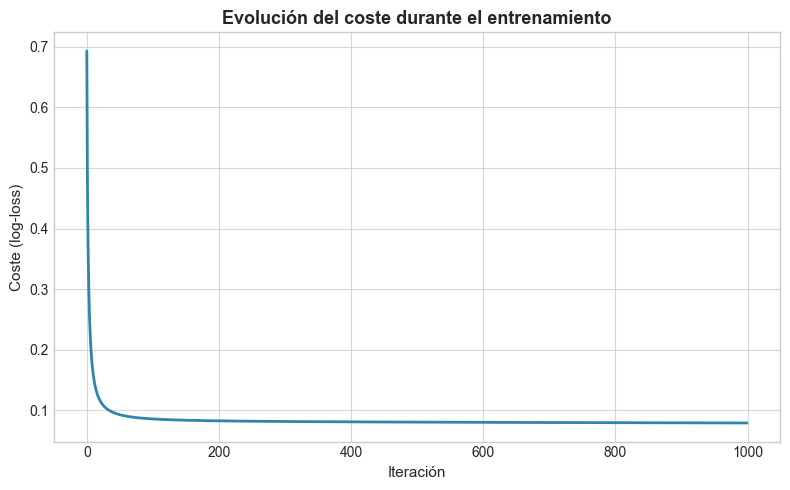

In [32]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))
plt.plot(J, color='#2E86AB', linewidth=2)
plt.title('Evolución del coste durante el entrenamiento', fontsize=13, fontweight='bold')
plt.grid(alpha = 0.8)
plt.xlabel('Iteración', fontsize=11)
plt.ylabel('Coste (log-loss)', fontsize=11)
plt.tight_layout()
plt.savefig('coste_entrenamiento.png', dpi=200, bbox_inches='tight')
plt.show()

# Evaluación

Uso el modelo para predecir la probabilidad de ser púlsar o no, y si es mayor o igual que 0,5 se considera púlsar. 

### Predicción sobre el test

In [ ]:
z = X_test_np@w + b

p = sigmoide(z)

for indice, probabilidad in enumerate(p):
    if p[indice] >= 0.5: 
        p[indice] = 1
    else:
        p[indice] = 0 


print(p)     

[0. 1. 0. ... 0. 0. 0.]


Para obtener la matriz de confusión, calculo el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

In [ ]:
vp = 0
vn = 0 
fp = 0 
fn = 0 

for i, variable in enumerate(p):
    if p[i]  == 1 and y_test_np[i] == 1:
        vp +=1
    if p[i] == 1 and y_test_np[i] == 0:
        fp +=1 
    if p[i] != 1 and y_test_np[i]== 0:
        vn += 1 
    if p[i]== 0 and y_test_np[i] == 1:
        fn +=1


print(vp, vn, fp, fn)
print(vp+vn+fp+fn)


270 3235 18 57
3580


### Accuracy, precision, recall, F1-score

La exactitud (accuracy) se calcula como

$$
\text{Exactitud} = \frac{VP + VN}{VP + VN + FP + FN}
$$

La precisión (precision) se calcula como

$$
\text{Precisión} = \frac{VP}{VP + FP}
$$

In [ ]:
exactitud = (vp+vn)/(vp+vn+fp+fn)
precision = (vp)/(vp+fp)

print(f"La exactitud del modelo es: {exactitud:.2%}")
print(f"La precisión del modelo es: {precision:.2%}")

La exactitud del modelo es: 97.91%
La precisión del modelo es: 93.75%


El recall significa: 

¿De todos los púlsars que había, cuántos consiguió encontrar el modelo?

In [ ]:
recall = (vp)/(vp+fn)
print(f"El recall del modelo es: {recall:.2%}")

El recall del modelo es: 82.57%


La F1-score es una medida que es alta cuando tanto la exactitud como la precisión del modelo son altas. 

$$

F_1=

\frac{2\cdot \text{Precision}\cdot\text{Recall}}

{\text{Precision}+\text{Recall}}

$$

In [ ]:
f1 = (2*precision*recall)/(precision+recall)

print(f"F1-score = {f1:.2f}")

F1-score = 0.88


### Matriz de confusión 

In [ ]:
print("            Predicción")
print("           0        1")
print(f"Real 0   {vn:4d}    {fp:4d}")
print(f"Real 1   {fn:4d}    {vp:4d}")

            Predicción
           0        1
Real 0   3235      18
Real 1     57     270


## Evaluación con L1

In [48]:
z_l1 = X_test_np@w_l1 + b_l1

p_l1 = sigmoide(z_l1)

for indice, probabilidad in enumerate(p_l1):
    if p_l1[indice] >= 0.5: 
        p_l1[indice] = 1
    else:
        p_l1[indice] = 0 


vp_l1 = 0
vn_l1 = 0 
fp_l1 = 0 
fn_l1 = 0 

for i, variable in enumerate(p_l1):
    if p_l1[i]  == 1 and y_test_np[i] == 1:
        vp_l1 +=1
    if p_l1[i] == 1 and y_test_np[i] == 0:
        fp_l1 +=1 
    if p_l1[i] != 1 and y_test_np[i]== 0:
        vn_l1 += 1 
    if p_l1[i]== 0 and y_test_np[i] == 1:
        fn_l1 +=1


exactitud_l1 = (vp_l1+vn_l1)/(vp_l1+vn_l1+fp_l1+fn_l1)
precision_l1 = (vp_l1)/(vp_l1+fp_l1)


recall_l1 = (vp_l1)/(vp_l1+fn_l1)
f1_l1 = (2*precision_l1*recall_l1)/(precision_l1+recall_l1)


print(f"El recall del modelo corregido con L1 es: {recall_l1:.2%}")
print(f"F1-score del modelo corregido con L1 es: {f1_l1:.2f}")

print(f"La exactitud del modelo corregido con L1 es: {exactitud_l1:.2%}")
print(f"La precisión del modelo corregido con L1 es: {precision_l1:.2%}")

El recall del modelo corregido con L1 es: 81.65%
F1-score del modelo corregido con L1 es: 0.88
La exactitud del modelo corregido con L1 es: 97.88%
La precisión del modelo corregido con L1 es: 94.35%


## Evaluación con L2

In [47]:
z_l2 = X_test_np@w_l2 + b_l2

p_l2 = sigmoide(z_l2)

for indice, probabilidad in enumerate(p_l2):
    if p_l2[indice] >= 0.5: 
        p_l2[indice] = 1
    else:
        p_l2[indice] = 0 


vp_l2 = 0
vn_l2 = 0 
fp_l2 = 0 
fn_l2 = 0 

for i, variable in enumerate(p_l2):
    if p_l2[i]  == 1 and y_test_np[i] == 1:
        vp_l2 +=1
    if p_l2[i] == 1 and y_test_np[i] == 0:
        fp_l2 +=1 
    if p_l2[i] != 1 and y_test_np[i]== 0:
        vn_l2 += 1 
    if p_l2[i]== 0 and y_test_np[i] == 1:
        fn_l2 +=1
        

exactitud_l2 = (vp_l2+vn_l2)/(vp_l2+vn_l2+fp_l2+fn_l2)
precision_l2 = (vp_l2)/(vp_l2+fp_l2)

recall_l2 = (vp_l2)/(vp_l2+fn_l2)
f1_l2 = (2*precision_l2*recall_l2)/(precision_l2+recall_l2)

print(f"El recall del modelo corregido con L2 es: {recall_l2:.2%}")
print(f"F1-score del modelo corregido con L2 es: {f1_l2:.2f}")

print(f"La exactitud del modelo corregido con L2 es: {exactitud_l2:.2%}")
print(f"La precisión del modelo corregido con L2 es: {precision_l2:.2%}")

El recall del modelo corregido con L2 es: 81.04%
F1-score del modelo corregido con L2 es: 0.87
La exactitud del modelo corregido con L2 es: 97.79%
La precisión del modelo corregido con L2 es: 93.97%


## Conclusiones de la regularización: sin regularizar, L1, L2

| Métrica    | Sin regularizar | L1 (λ=15) | L2 (λ=15) |
|------------|:----------------:|:---------:|:---------:|
| Accuracy   | 97.91%           | 97.88%    | 97.79%    |
| Precision  | 93.75%           | 94.35%    | 93.97%    |
| Recall     | 82.57%           | 81.65%    | 81.04%    |
| F1-score   | 0.878            | 0.88      | 0.87      |


Como el modelo no tenía aspecto de overfitting, la regularización no ha mejorado nada. Lo único que ha hecho es introducir una restricción articficial (obligar a que los pesos sean más pequeños), entonces empeora un poco el ajuste del modelo.

En cuanto a los pesos: L1 llevó `Profile_kurtosis`
casi a cero (0.60 a 0.02), casi anulando la variable, mientras que L2 suavizó de forma más uniforme el peso de `Profile_skewness` (3.20 a 2.43).

Esto confirma que ambas técnicas funcionan, aunque en
este caso concreto no hacían fatla para mejorar en el modelo. 